In [31]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.tree import _tree

import warnings
warnings.filterwarnings('ignore')


In [32]:


def extract_rules_from_tree(tree, feature_names):
    tree_ = tree.tree_
    features = [feature_names[i] if i != _tree.TREE_UNDEFINED
                else "undefined" for i in tree_.feature]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            class_counts = tree_.value[node][0]
            total = class_counts.sum()
            prob1 = float(class_counts[1] / total) if total > 0 else 0.5
            rules.append({
                'conditions': tuple(sorted(conditions)),
                'prediction': int(np.argmax(class_counts)),
                'prob_class1': prob1,
                'samples': int(tree_.n_node_samples[node]),
                'impurity': float(tree_.impurity[node]),
            })
            return
        feat = features[node]
        thr = round(float(tree_.threshold[node]), 4)
        recurse(tree_.children_left[node],
                conditions + [(feat, '<=', thr)])
        recurse(tree_.children_right[node],
                conditions + [(feat, '>', thr)])

    recurse(0, [])
    return rules


def rule_key(conditions):
    return "|".join(f"{f}{op}{t}" for f, op, t in conditions)


def instance_satisfies(row, conditions):

    for f, op, t in conditions:
        v = row[f]
        if op == '<=' and not (v <= t):
            return False
        if op == '>' and not (v > t):
            return False
    return True


def humanize_conditions(conditions, bin_edges):
    out = []
    for f, op, t in conditions:
        edge_idx = int(np.ceil(t))
        edge_idx = min(edge_idx, len(bin_edges[f]) - 1)
        real_val = float(bin_edges[f][edge_idx])
        out.append((f, op, round(real_val, 4)))
    return out


def sirus_predict(kept_rules, rule_examples, X_df, prior_class):
    preds = []
    fired_counts = []
    for _, row in X_df.iterrows():
        score = {0: 0.0, 1: 0.0}
        n_fired = 0
        for key, count in kept_rules:
            rule = rule_examples[key]
            if instance_satisfies(row, rule['conditions']):
                score[1] += count * rule['prob_class1']
                score[0] += count * (1 - rule['prob_class1'])
                n_fired += 1
        if score[0] == 0 and score[1] == 0:
            preds.append(prior_class)
        else:
            preds.append(1 if score[1] >= score[0] else 0)
        fired_counts.append(n_fired)
    return np.array(preds), fired_counts


def run_sirus_pipeline(X_train, X_test, y_train, y_test, feature_names,
                       n_bins=10, n_estimators=500, max_depth=2,
                       random_state=42):

    disc = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                            strategy='quantile')
    X_train_d = pd.DataFrame(disc.fit_transform(X_train),
                             columns=feature_names)
    X_test_d = pd.DataFrame(disc.transform(X_test),
                            columns=feature_names)


    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        max_features=None,         
        bootstrap=True, n_jobs=-1, random_state=random_state,
    )
    rf.fit(X_train_d, y_train)


    rule_counts = Counter()
    rule_examples = {}
    for est in rf.estimators_:
        for r in extract_rules_from_tree(est, feature_names):
            if not r['conditions']:
                continue
            k = rule_key(r['conditions'])
            rule_counts[k] += 1
            if k not in rule_examples:
                rule_examples[k] = r

    bin_edges = {f: disc.bin_edges_[i] for i, f in enumerate(feature_names)}

    return {
        'rf': rf,
        'X_train_d': X_train_d,
        'X_test_d': X_test_d,
        'rule_counts': rule_counts,
        'rule_examples': rule_examples,
        'bin_edges': bin_edges,
        'n_estimators': n_estimators,
    }


In [33]:


bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = pd.Series(bc.target, name='target')
fnames_bc = list(bc.feature_names)

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

print("Running SIRUS pipeline on breast cancer...")
sirus_bc = run_sirus_pipeline(
    X_bc_tr, X_bc_te, y_bc_tr, y_bc_te, fnames_bc,
    n_bins=10, n_estimators=500, max_depth=2,
)


rf_bc_preds = sirus_bc['rf'].predict(sirus_bc['X_test_d'])
rf_bc_acc = accuracy_score(y_bc_te, rf_bc_preds)
rf_bc_f1 = f1_score(y_bc_te, rf_bc_preds)
print(f"Shallow RF baseline: acc={rf_bc_acc:.4f} f1={rf_bc_f1:.4f}")
print(f"Total unique canonical rules: {len(sirus_bc['rule_counts'])}")


Running SIRUS pipeline on breast cancer...
Shallow RF baseline: acc=0.9474 f1=0.9577
Total unique canonical rules: 341


p0 sweep on breast cancer:
  p0=0.01 (>= 5 trees) -> 103 rules | acc=0.9561 f1=0.9650 pos_recall=0.9583
  p0=0.02 (>= 10 trees) ->  54 rules | acc=0.9561 f1=0.9650 pos_recall=0.9583
  p0=0.03 (>= 15 trees) ->  32 rules | acc=0.9561 f1=0.9655 pos_recall=0.9722
  p0=0.05 (>= 25 trees) ->  13 rules | acc=0.9649 f1=0.9722 pos_recall=0.9722
  p0=0.08 (>= 40 trees) ->   8 rules | acc=0.9211 f1=0.9371 pos_recall=0.9306
  p0=0.10 (>= 50 trees) ->   6 rules | acc=0.9211 f1=0.9371 pos_recall=0.9306
  p0=0.15 (>= 75 trees) ->   1 rules | acc=0.9298 f1=0.9444 pos_recall=0.9444


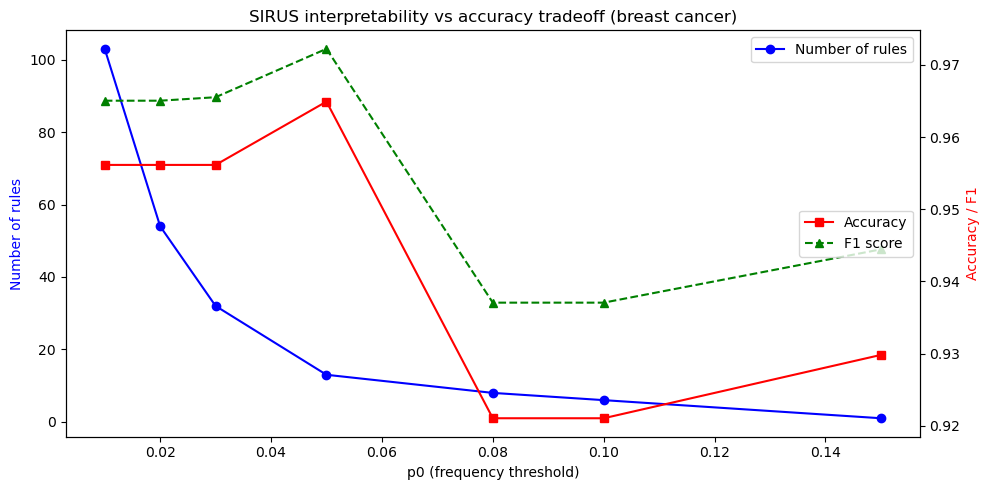

In [34]:

p0_grid = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15]
p0_results_bc = []  # (p0, n_rules, acc, f1, pos_recall)

prior_class_bc = int(y_bc_tr.mean() >= 0.5)

print("p0 sweep on breast cancer:")
for p0 in p0_grid:
    min_count = int(np.ceil(p0 * sirus_bc['n_estimators']))
    kept = [(k, c) for k, c in sirus_bc['rule_counts'].items()
            if c >= min_count]
    kept.sort(key=lambda kv: -kv[1])
    if not kept:
        p0_results_bc.append((p0, 0, np.nan, np.nan, np.nan))
        print(f"  p0={p0:.2f} -> 0 rules (skipped)")
        continue
    preds, _ = sirus_predict(
        kept, sirus_bc['rule_examples'], sirus_bc['X_test_d'], prior_class_bc
    )
    acc = accuracy_score(y_bc_te, preds)
    f1v = f1_score(y_bc_te, preds, zero_division=0)
    rec = recall_score(y_bc_te, preds, pos_label=1, zero_division=0)
    p0_results_bc.append((p0, len(kept), acc, f1v, rec))
    print(f"  p0={p0:.2f} (>= {min_count} trees) -> {len(kept):>3} rules"
          f" | acc={acc:.4f} f1={f1v:.4f} pos_recall={rec:.4f}")

# Tradeoff plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
xs = [r[0] for r in p0_results_bc]
ax1.plot(xs, [r[1] for r in p0_results_bc], 'bo-', label='Number of rules')
ax2.plot(xs, [r[2] for r in p0_results_bc], 'rs-', label='Accuracy')
ax2.plot(xs, [r[3] for r in p0_results_bc], 'g^--', label='F1 score')
ax1.set_xlabel('p0 (frequency threshold)')
ax1.set_ylabel('Number of rules', color='blue')
ax2.set_ylabel('Accuracy / F1', color='red')
plt.title('SIRUS interpretability vs accuracy tradeoff (breast cancer)')
ax1.legend(loc='upper right')
ax2.legend(loc='center right')
plt.tight_layout()
plt.savefig('sirus_bc_tradeoff.png', dpi=150)
plt.show()


In [35]:

chosen_p0_bc = 0.05
min_count = int(np.ceil(chosen_p0_bc * sirus_bc['n_estimators']))
kept_bc = [(k, c) for k, c in sirus_bc['rule_counts'].items()
           if c >= min_count]
kept_bc.sort(key=lambda kv: -kv[1])


sirus_bc_preds, fired_bc = sirus_predict(
    kept_bc, sirus_bc['rule_examples'], sirus_bc['X_test_d'], prior_class_bc
)
sirus_bc_acc = accuracy_score(y_bc_te, sirus_bc_preds)
sirus_bc_f1 = f1_score(y_bc_te, sirus_bc_preds)

print(f"Final SIRUS rule set (p0={chosen_p0_bc}): {len(kept_bc)} rules")
print(f"Accuracy: {sirus_bc_acc:.4f}  F1: {sirus_bc_f1:.4f}")
print(f"Avg rules firing per instance: {np.mean(fired_bc):.1f}")
print(classification_report(y_bc_te, sirus_bc_preds,target_names=['Malignant', 'Benign']))


print(f"\nAll {len(kept_bc)} SIRUS rules (sorted by frequency):")
for i, (k, count) in enumerate(kept_bc):
    rule = sirus_bc['rule_examples'][k]
    label = 'Benign' if rule['prediction'] == 1 else 'Malignant'
    freq_pct = 100 * count / sirus_bc['n_estimators']
    print(f"\nRule {i+1:02d}  {label}  freq={count}/{sirus_bc['n_estimators']}"
          f" ({freq_pct:.1f}%) leaf prob_benign={rule['prob_class1']:.2f}")
    for f, op, t in humanize_conditions(rule['conditions'], sirus_bc['bin_edges']):
        print(f"  IF {f} {op} {t}")


Final SIRUS rule set (p0=0.05): 13 rules
Accuracy: 0.9649  F1: 0.9722
Avg rules firing per instance: 3.9
              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        42
      Benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


All 13 SIRUS rules (sorted by frequency):

Rule 01  Malignant  freq=82/500 (16.4%) leaf prob_benign=0.01
  IF mean concave points > 0.0458
  IF worst perimeter > 104.54

Rule 02  Benign  freq=71/500 (14.2%) leaf prob_benign=0.99
  IF worst concave points <= 0.1785
  IF worst perimeter <= 104.54

Rule 03  Malignant  freq=71/500 (14.2%) leaf prob_benign=0.00
  IF worst concave points > 0.1785
  IF worst perimeter <= 104.54

Rule 04  Benign  freq=70/500 (14.0%) leaf prob_benign=0.64
  IF mean concave points <= 0.0458
  IF worst perimeter > 104.54

Rule 05  Benign 

In [36]:


df_p = pd.read_csv('diabetes.csv')
X_p = df_p.drop(columns=['Outcome'])
y_p = df_p['Outcome']
fnames_p = list(X_p.columns)

X_p_tr, X_p_te, y_p_tr, y_p_te = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42, stratify=y_p
)

print("Running SIRUS pipeline on Pima...")
sirus_p = run_sirus_pipeline(
    X_p_tr, X_p_te, y_p_tr, y_p_te, fnames_p,
    n_bins=10, n_estimators=500, max_depth=2,
)

rf_p_preds = sirus_p['rf'].predict(sirus_p['X_test_d'])
rf_p_acc = accuracy_score(y_p_te, rf_p_preds)
rf_p_f1 = f1_score(y_p_te, rf_p_preds)
print(f"Shallow RF baseline: acc={rf_p_acc:.4f} f1={rf_p_f1:.4f}")
print(f"Total unique canonical rules: {len(sirus_p['rule_counts'])}")


Running SIRUS pipeline on Pima...
Shallow RF baseline: acc=0.7013 f1=0.5400
Total unique canonical rules: 203


p0 sweep on Pima:
  p0=0.01 (>= 5 trees) ->  62 rules acc=0.7143 f1=0.5417 diab_recall=0.4815
  p0=0.02 (>= 10 trees) ->  34 rules acc=0.7143 f1=0.5417 diab_recall=0.4815
  p0=0.03 (>= 15 trees) ->  26 rules acc=0.7143 f1=0.5417 diab_recall=0.4815
  p0=0.05 (>= 25 trees) ->  18 rules acc=0.7143 f1=0.5417 diab_recall=0.4815
  p0=0.08 (>= 40 trees) ->  14 rules acc=0.7143 f1=0.5417 diab_recall=0.4815
  p0=0.10 (>= 50 trees) ->  12 rules acc=0.7143 f1=0.5417 diab_recall=0.4815
  p0=0.15 (>= 75 trees) ->   8 rules acc=0.7143 f1=0.5417 diab_recall=0.4815


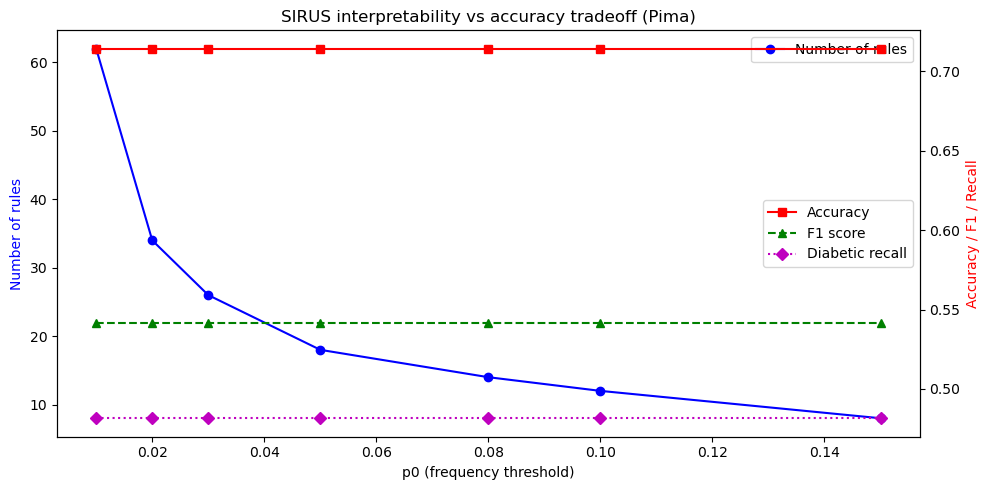

In [37]:
# Same sweep as breast cancer.
p0_results_p = []
prior_class_p = int(y_p_tr.mean() >= 0.5)

print("p0 sweep on Pima:")
for p0 in p0_grid:
    min_count = int(np.ceil(p0 * sirus_p['n_estimators']))
    kept = [(k, c) for k, c in sirus_p['rule_counts'].items()
            if c >= min_count]
    kept.sort(key=lambda kv: -kv[1])
    if not kept:
        p0_results_p.append((p0, 0, np.nan, np.nan, np.nan))
        print(f"  p0={p0:.2f} -> 0 rules (skipped)")
        continue
    preds, _ = sirus_predict(
        kept, sirus_p['rule_examples'], sirus_p['X_test_d'], prior_class_p
    )
    acc = accuracy_score(y_p_te, preds)
    f1v = f1_score(y_p_te, preds, zero_division=0)
    rec = recall_score(y_p_te, preds, pos_label=1, zero_division=0)
    p0_results_p.append((p0, len(kept), acc, f1v, rec))
    print(f"  p0={p0:.2f} (>= {min_count} trees) -> {len(kept):>3} rules"
          f" acc={acc:.4f} f1={f1v:.4f} diab_recall={rec:.4f}")


fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
xs = [r[0] for r in p0_results_p]
ax1.plot(xs, [r[1] for r in p0_results_p], 'bo-', label='Number of rules')
ax2.plot(xs, [r[2] for r in p0_results_p], 'rs-', label='Accuracy')
ax2.plot(xs, [r[3] for r in p0_results_p], 'g^--', label='F1 score')
ax2.plot(xs, [r[4] for r in p0_results_p], 'mD:', label='Diabetic recall')
ax1.set_xlabel('p0 (frequency threshold)')
ax1.set_ylabel('Number of rules', color='blue')
ax2.set_ylabel('Accuracy / F1 / Recall', color='red')
plt.title('SIRUS interpretability vs accuracy tradeoff (Pima)')
ax1.legend(loc='upper right')
ax2.legend(loc='center right')
plt.tight_layout()
plt.savefig('sirus_pima_tradeoff.png', dpi=150)
plt.show()


In [38]:
# Pick p0 for Pima. p0=0.10 gives ~12 rules — comparable to the
# breast cancer rule count for a like-for-like comparison.
chosen_p0_p = 0.10
min_count = int(np.ceil(chosen_p0_p * sirus_p['n_estimators']))
kept_p = [(k, c) for k, c in sirus_p['rule_counts'].items()
          if c >= min_count]
kept_p.sort(key=lambda kv: -kv[1])

sirus_p_preds, fired_p = sirus_predict(
    kept_p, sirus_p['rule_examples'], sirus_p['X_test_d'], prior_class_p
)
sirus_p_acc = accuracy_score(y_p_te, sirus_p_preds)
sirus_p_f1 = f1_score(y_p_te, sirus_p_preds)
sirus_p_recall = recall_score(y_p_te, sirus_p_preds, pos_label=1)

print(f"Final SIRUS rule set (p0={chosen_p0_p}): {len(kept_p)} rules")
print(f"Accuracy: {sirus_p_acc:.4f} F1: {sirus_p_f1:.4f} "
      f" Diabetic recall: {sirus_p_recall:.4f}")
print(f"Avg rules firing per instance: {np.mean(fired_p):.1f}")
print(classification_report(y_p_te, sirus_p_preds,target_names=['Non-diabetic', 'Diabetic']))

print(f"\nAll {len(kept_p)} SIRUS rules:")
for i, (k, count) in enumerate(kept_p):
    rule = sirus_p['rule_examples'][k]
    label = 'Diabetic' if rule['prediction'] == 1 else 'Non-diabetic'
    freq_pct = 100 * count / sirus_p['n_estimators']
    print(f"\nRule {i+1:02d} {label} freq={count}/{sirus_p['n_estimators']}"
          f" ({freq_pct:.1f}%) leaf prob_diab={rule['prob_class1']:.2f}")
    for f, op, t in humanize_conditions(rule['conditions'], sirus_p['bin_edges']):
        print(f"  IF {f} {op} {t}")


Final SIRUS rule set (p0=0.1): 12 rules
Accuracy: 0.7143 F1: 0.5417  Diabetic recall: 0.4815
Avg rules firing per instance: 2.6
              precision    recall  f1-score   support

Non-diabetic       0.75      0.84      0.79       100
    Diabetic       0.62      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


All 12 SIRUS rules:

Rule 01 Non-diabetic freq=115/500 (23.0%) leaf prob_diab=0.34
  IF BMI <= 30.1
  IF Glucose > 134.0

Rule 02 Diabetic freq=115/500 (23.0%) leaf prob_diab=0.77
  IF BMI > 30.1
  IF Glucose > 134.0

Rule 03 Non-diabetic freq=114/500 (22.8%) leaf prob_diab=0.09
  IF Age <= 29.0
  IF Glucose <= 134.0

Rule 04 Non-diabetic freq=114/500 (22.8%) leaf prob_diab=0.33
  IF Age > 29.0
  IF Glucose <= 134.0

Rule 05 Diabetic freq=87/500 (17.4%) leaf prob_diab=0.55
  IF Glucose <= 167.0
  IF Glucose > 134.0

Rule 06 Diabetic freq=

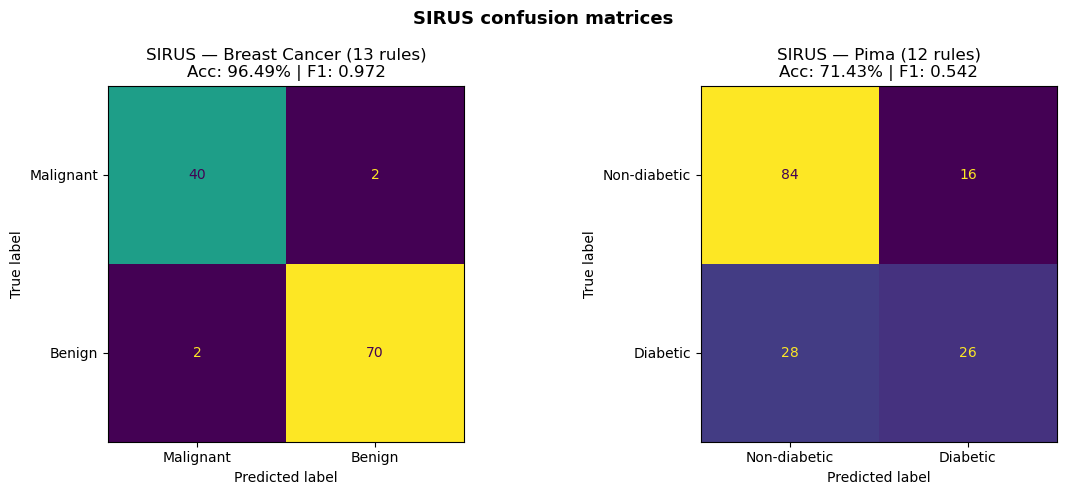

In [39]:
# Side-by-side confusion matrices for SIRUS on both datasets.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_bc = confusion_matrix(y_bc_te, sirus_bc_preds)
ConfusionMatrixDisplay(cm_bc, display_labels=['Malignant', 'Benign'])\
    .plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'SIRUS — Breast Cancer ({len(kept_bc)} rules)\n'
                  f'Acc: {sirus_bc_acc*100:.2f}% | F1: {sirus_bc_f1:.3f}')

cm_p = confusion_matrix(y_p_te, sirus_p_preds)
ConfusionMatrixDisplay(cm_p, display_labels=['Non-diabetic', 'Diabetic'])\
    .plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'SIRUS — Pima ({len(kept_p)} rules)\n'
                  f'Acc: {sirus_p_acc*100:.2f}% | F1: {sirus_p_f1:.3f}')

plt.suptitle('SIRUS confusion matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sirus_confusion_matrices.png', dpi=150)
plt.show()


In [40]:


def run_sirus_balanced(X_train, X_test, y_train, y_test, feature_names,
                       n_bins=10, n_estimators=500, max_depth=2,
                       random_state=42):
    """Same SIRUS pipeline but with class_weight='balanced'."""
    disc = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                            strategy='quantile')
    X_train_d = pd.DataFrame(disc.fit_transform(X_train),
                             columns=feature_names)
    X_test_d = pd.DataFrame(disc.transform(X_test),
                            columns=feature_names)

    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        max_features=None, bootstrap=True, n_jobs=-1,
        random_state=random_state,
        class_weight='balanced',   
    )
    rf.fit(X_train_d, y_train)

    rule_counts = Counter(); rule_examples = {}
    for est in rf.estimators_:
        for r in extract_rules_from_tree(est, feature_names):
            if not r['conditions']: continue
            k = rule_key(r['conditions'])
            rule_counts[k] += 1
            if k not in rule_examples:
                rule_examples[k] = r
    bin_edges = {f: disc.bin_edges_[i] for i, f in enumerate(feature_names)}
    return {'rf': rf, 'X_train_d': X_train_d, 'X_test_d': X_test_d,
            'rule_counts': rule_counts, 'rule_examples': rule_examples,
            'bin_edges': bin_edges, 'n_estimators': n_estimators}


# Run balanced SIRUS on breast cancer
print("Running balanced SIRUS on breast cancer...")
sirus_bc_b = run_sirus_balanced(X_bc_tr, X_bc_te, y_bc_tr, y_bc_te,
                                fnames_bc, n_estimators=500, max_depth=2)


chosen_p0_bc_b = 0.05
mc = int(np.ceil(chosen_p0_bc_b * sirus_bc_b['n_estimators']))
kept_bc_b = [(k, c) for k, c in sirus_bc_b['rule_counts'].items() if c >= mc]
kept_bc_b.sort(key=lambda kv: -kv[1])

sirus_bc_b_preds, _ = sirus_predict(
    kept_bc_b, sirus_bc_b['rule_examples'], sirus_bc_b['X_test_d'],
    prior_class_bc
)
sirus_bc_b_acc = accuracy_score(y_bc_te, sirus_bc_b_preds)
sirus_bc_b_f1 = f1_score(y_bc_te, sirus_bc_b_preds)
sirus_bc_b_recall = recall_score(y_bc_te, sirus_bc_b_preds, pos_label=1)

print(f"Balanced SIRUS (BC, p0={chosen_p0_bc_b}): {len(kept_bc_b)} rules"
      f" | acc={sirus_bc_b_acc:.4f} f1={sirus_bc_b_f1:.4f}"
      f" benign_recall={sirus_bc_b_recall:.4f}")


Running balanced SIRUS on breast cancer...
Balanced SIRUS (BC, p0=0.05): 26 rules | acc=0.9386 f1=0.9504 benign_recall=0.9306


In [42]:


print("Running balanced SIRUS on Pima...")
sirus_p_b = run_sirus_balanced(X_p_tr, X_p_te, y_p_tr, y_p_te,fnames_p, n_estimators=500, max_depth=2)


chosen_p0_p_b = 0.10
mc = int(np.ceil(chosen_p0_p_b * sirus_p_b['n_estimators']))
kept_p_b = [(k, c) for k, c in sirus_p_b['rule_counts'].items() if c >= mc]
kept_p_b.sort(key=lambda kv: -kv[1])

sirus_p_b_preds, _ = sirus_predict(
    kept_p_b, sirus_p_b['rule_examples'], sirus_p_b['X_test_d'],
    prior_class_p
)
sirus_p_b_acc = accuracy_score(y_p_te, sirus_p_b_preds)
sirus_p_b_f1 = f1_score(y_p_te, sirus_p_b_preds)
sirus_p_b_recall = recall_score(y_p_te, sirus_p_b_preds, pos_label=1)

n_diab_b = sum(1 for k, _ in kept_p_b
               if sirus_p_b['rule_examples'][k]['prediction'] == 1)
n_nondiab_b = len(kept_p_b) - n_diab_b

print(f"Balanced SIRUS (Pima, p0={chosen_p0_p_b}): {len(kept_p_b)} rules" )
print(f"  acc={sirus_p_b_acc:.4f} f1={sirus_p_b_f1:.4f}"
      f" diab_recall={sirus_p_b_recall:.4f}")
print(classification_report(y_p_te, sirus_p_b_preds, target_names=['Non-diabetic', 'Diabetic']))


print(f"\nAll {len(kept_p_b)} balanced SIRUS rules (Pima):")
for i, (k, count) in enumerate(kept_p_b):
    rule = sirus_p_b['rule_examples'][k]
    label = 'Diabetic' if rule['prediction'] == 1 else 'Non-diabetic'
    freq_pct = 100 * count / sirus_p_b['n_estimators']
    print(f"\nRule {i+1:02d}  {label} freq={count}/{sirus_p_b['n_estimators']}"
          f" ({freq_pct:.1f}%)  leaf prob_diab={rule['prob_class1']:.2f}")
    for f, op, t in humanize_conditions(rule['conditions'],sirus_p_b['bin_edges']):
        print(f"  IF {f} {op} {t}")


Running balanced SIRUS on Pima...
Balanced SIRUS (Pima, p0=0.1): 10 rules
  acc=0.6948 f1=0.5841 diab_recall=0.6111
              precision    recall  f1-score   support

Non-diabetic       0.78      0.74      0.76       100
    Diabetic       0.56      0.61      0.58        54

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.70       154


All 10 balanced SIRUS rules (Pima):

Rule 01  Diabetic freq=129/500 (25.8%)  leaf prob_diab=0.51
  IF BMI <= 30.1
  IF Glucose > 125.0

Rule 02  Diabetic freq=129/500 (25.8%)  leaf prob_diab=0.83
  IF BMI > 30.1
  IF Glucose > 125.0

Rule 03  Non-diabetic freq=121/500 (24.2%)  leaf prob_diab=0.10
  IF Age <= 29.0
  IF Glucose <= 125.0

Rule 04  Non-diabetic freq=121/500 (24.2%)  leaf prob_diab=0.44
  IF Age > 29.0
  IF Glucose <= 125.0

Rule 05  Diabetic freq=117/500 (23.4%)  leaf prob_diab=0.55
  IF BMI <= 30.1
  IF Glucose > 134.0

Rule 06  Diabeti